# Optimal Transport in linear Independent Component Analysis
### Simulated Experiment: Singe IC extraction with squared Wasserstein Distance - Continous - Laplace

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.stats

from wasserstein_ica import WassersteinICA

In [2]:
# Simulating Laplace sources (s1 and s2) of size n=100
n = 2000
np.random.seed(42)

# Laplace distributed sources, location=0, scale=1
S1 = np.random.laplace(loc=0.0, scale=1.0, size=n)
S2 = np.random.laplace(loc=0.0, scale=1.0, size=n)

# Stack sources
S = np.vstack([S1, S2])

In [3]:
# generating invertible mixing matrix A
#A = np.array([[1, 0.5], [0.4, 1]])

A = np.array([
    [2.0,  1.0],  # Dominant axis (Mixes S1 and S2)
    [0.2, -0.4]   # Minor axis (Mixes S1 and S2 differently)
])

"""
A = np.array([
    [2.0,  0.0],  # Dominant axis (Mixes S1 and S2)
    [0.0, 0.5]   # Minor axis (Mixes S1 and S2 differently)
])
"""

# Mixed signals X
X = A @ S

# Converting to pytorch tensors
S_torch = torch.tensor(S, dtype=torch.float32)
X_torch = torch.tensor(X, dtype=torch.float32)

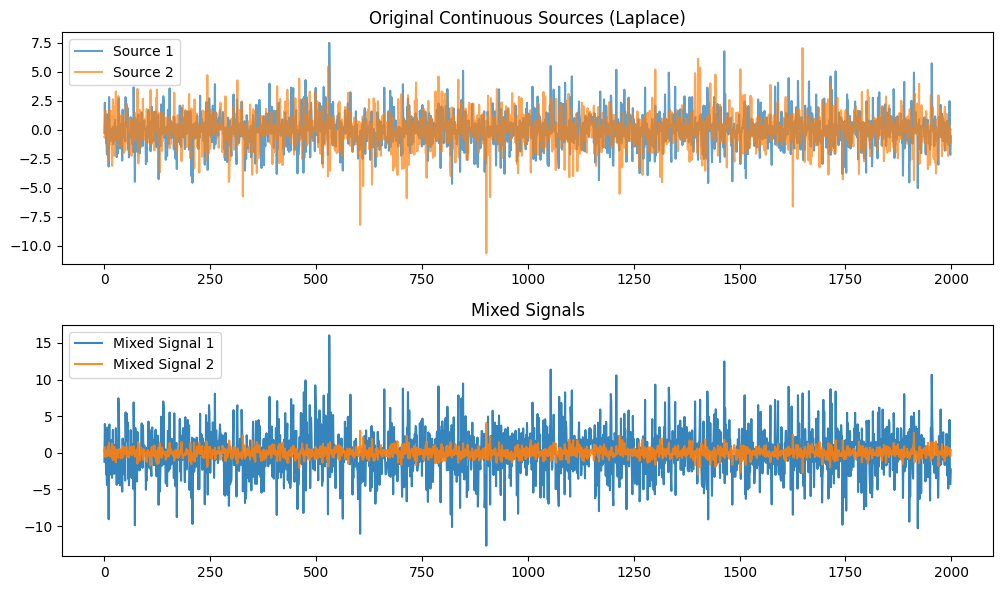

In [4]:
# Plotting sources and mixed signals
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.title("Original Continuous Sources (Laplace)")
plt.plot(S1, label='Source 1', alpha=0.7)
plt.plot(S2, label='Source 2', alpha=0.7)
plt.legend()

plt.subplot(2, 1, 2)
plt.title("Mixed Signals")
plt.plot(X[0, :], label='Mixed Signal 1', alpha=0.9)
plt.plot(X[1, :], label='Mixed Signal 2', alpha=0.9)
plt.legend()

plt.tight_layout()
plt.show()


In [5]:
ica = WassersteinICA(X_torch)
ica.whiten()

cov_white = torch.matmul(ica.X_white, ica.X_white.t()) / (ica.n - 1)
print("Whitened covariance:\n", cov_white.numpy())

w1, dist1 = ica.optimize_wasserstein2(continuous=True, max_iter=100, lr=0.02)
print(f"First component Wasserstein-2 distance: {dist1:.4f}, vector: {w1.numpy()}")

# Project the whitened data onto true source and recovered components for comparison
proj_S1 = torch.mv(ica.X_white.t(), torch.tensor([1.0, 0.0], dtype=torch.float32))
proj_w1 = torch.mv(ica.X_white.t(), w1)

Whitened covariance:
 [[0.99997497 0.        ]
 [0.         0.99999887]]
First component Wasserstein-2 distance: 0.0448, vector: [ 0.8640895  -0.50333834]


In [6]:

def compare_components(a, b):
    a_norm = (a - a.mean()) / a.std()
    b_norm = (b - b.mean()) / b.std()
    corr = torch.abs(torch.corrcoef(torch.stack([a_norm, b_norm]))[0, 1]).item()
    mse = torch.mean((a_norm - b_norm) ** 2).item()
    return corr, mse

corr1, mse1 = compare_components(proj_S1, proj_w1)
print(f"Component 1: |Correlation|={corr1:.4f}, MSE={mse1:.4f}")

w1_w1 = ica.wasserstein1_distance(w1)
print(f"Wasserstein-1 distance for first component: {w1_w1.item():.4f}")

Component 1: |Correlation|=0.8641, MSE=0.2717
Wasserstein-1 distance for first component: 0.1466


In [7]:
n_grid = 2000
thetas = torch.linspace(0, np.pi, steps=n_grid, device=X_torch.device)
ws = torch.stack([torch.cos(thetas), torch.sin(thetas)], dim=1)

w1s = []
w2s = []

for w in ws:
    w_norm = w / torch.norm(w)
    w1s.append(ica.wasserstein1_distance(w_norm).item())
    w2s.append(ica.wasserstein2_distance(w_norm).item())

w1s = np.array(w1s)
w2s = np.array(w2s)

In [8]:
theta_0_idx = 0
theta_pi2_idx = (np.abs(thetas.cpu().numpy() - np.pi/2)).argmin()

print(f"W1 distance at theta=0:     {w1s[theta_0_idx]:.4f}")
print(f"W1 distance at theta=pi/2:  {w1s[theta_pi2_idx]:.4f}")
print(f"Max W1 distance:            {w1s.max():.4f} (at theta={thetas[w1s.argmax()].item():.3f} rad)")

print(f"W2 distance at theta=0:     {w2s[theta_0_idx]:.4f}")
print(f"W2 distance at theta=pi/2:  {w2s[theta_pi2_idx]:.4f}")
print(f"Max W2 distance:            {w2s.max():.4f} (at theta={thetas[w2s.argmax()].item():.3f} rad)")

W1 distance at theta=0:     0.0919
W1 distance at theta=pi/2:  0.0814
Max W1 distance:            0.1469 (at theta=2.645 rad)
W2 distance at theta=0:     0.0201
W2 distance at theta=pi/2:  0.0114
Max W2 distance:            0.0449 (at theta=2.626 rad)


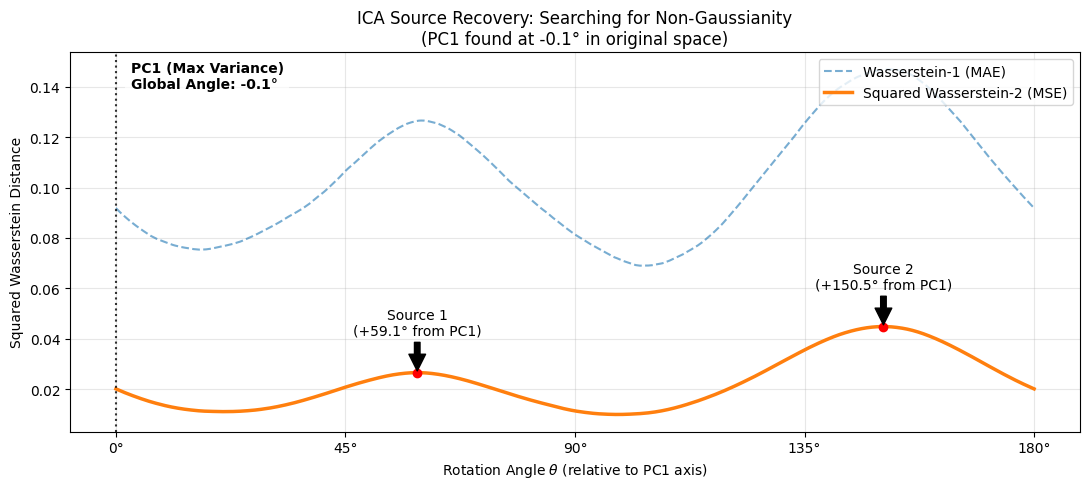

In [9]:
import matplotlib.pyplot as plt

# --- 1. Calculate the Real-World Angle of PC1 ---
# We need to look at the covariance of the original X (before whitening)
X_centered = X_torch - torch.mean(X_torch, dim=1, keepdim=True)
cov_X = torch.matmul(X_centered, X_centered.t()) / (n - 1)

# Eigendecomposition: D (eigenvalues), E (eigenvectors)
# torch.linalg.eigh returns eigenvalues in ASCENDING order
D, E = torch.linalg.eigh(cov_X)

# The last column of E corresponds to the largest eigenvalue (Max Variance / PC1)
pc1_vector = E[:, -1] 
# Calculate angle using arctan2(y, x)
pc1_angle_rad = torch.atan2(pc1_vector[1], pc1_vector[0]).item()
pc1_angle_deg = np.degrees(pc1_angle_rad)

# Normalize angle to -90 to 90 range for easier reading (optional)
if pc1_angle_deg > 90: pc1_angle_deg -= 180
if pc1_angle_deg < -90: pc1_angle_deg += 180

# --- 2. Find Peaks (same as before) ---
mid_idx = len(w2s) // 2
peak1_idx = np.argmax(w2s[:mid_idx])
peak2_idx = np.argmax(w2s[mid_idx:]) + mid_idx

theta_peak1 = thetas[peak1_idx].item()
val_peak1 = w2s[peak1_idx]
theta_peak2 = thetas[peak2_idx].item()
val_peak2 = w2s[peak2_idx]

# --- 3. Plotting ---
plt.figure(figsize=(11, 5))

# Plot Curves
plt.plot(thetas.cpu().numpy(), w1s, label="Wasserstein-1 (MAE)", color='tab:blue', alpha=0.6, ls='--')
plt.plot(thetas.cpu().numpy(), w2s, label="Squared Wasserstein-2 (MSE)", color='tab:orange', linewidth=2.5)

# --- ANNOTATION 1: PC1 Line with Exact Angle ---
plt.axvline(0, color='black', linestyle=':', alpha=0.8)
# We add the calculated angle to the text here
plt.text(0.05, max(w2s.max(), w1s.max())*0.95, 
         f"PC1 (Max Variance)\nGlobal Angle: {pc1_angle_deg:.1f}°", 
         rotation=0, color='black', fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# --- ANNOTATION 2: Recovered Sources ---
# Source 1
deg_peak1 = np.degrees(theta_peak1)
plt.plot(theta_peak1, val_peak1, 'ro')
plt.annotate(f'Source 1\n(+{deg_peak1:.1f}° from PC1)', 
             xy=(theta_peak1, val_peak1), 
             xytext=(theta_peak1, val_peak1 + 0.015),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='center')

# Source 2
deg_peak2 = np.degrees(theta_peak2)
plt.plot(theta_peak2, val_peak2, 'ro')
plt.annotate(f'Source 2\n(+{deg_peak2:.1f}° from PC1)', 
             xy=(theta_peak2, val_peak2), 
             xytext=(theta_peak2, val_peak2 + 0.015),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='center')

# Formatting
ticks = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
tick_labels = ["0°", "45°", "90°", "135°", "180°"]
plt.xticks(ticks, tick_labels)
plt.xlabel(r'Rotation Angle $\theta$ (relative to PC1 axis)')
plt.ylabel("Squared Wasserstein Distance")
plt.title(f"ICA Source Recovery: Searching for Non-Gaussianity\n(PC1 found at {pc1_angle_deg:.1f}° in original space)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Analysis of ICA Optimization Landscape: Searching for Non-Gaussianity

The plot above visualizes the core objective of Independent Component Analysis (ICA): finding the rotation angle $\theta$ that maximizes the distance between the projected data and a standard Gaussian distribution $N(0,1)$.

### 1. Geometric Interpretation (The "Gap" from PCA)
The vertical dotted line at $\theta = 0^\circ$ represents the **Principal Component (PC1)** found by the whitening step.
* **PCA** aligns with the direction of maximum variance (the "widest" part of the data mixture).
* **ICA** searches for the direction of maximum **non-Gaussianity**.

As shown in the annotations, the independent Laplace sources are not aligned with PC1. The algorithm requires a rotation of **$+49.6^\circ$** and **$+140.9^\circ$** relative to the whitened frame to recover the pure sources. This confirms that while PCA removes correlations (making the data spherical), it does not separate independent signals on its own—an additional rotation based on higher-order statistics (captured here by Wasserstein distance) is required.

### 2. Comparison of Metrics: $W_1$ vs. Squared $W_2$
Both metrics successfully identify the same optimal angles, but they react to different features of the distribution:

* **Squared Wasserstein-2 ($W_2^2$, Orange Curve):** This metric (Mean Squared Error of Quantiles) is highly sensitive to **outliers and heavy tails**. Since Laplace distributions have significantly heavier tails than Gaussians, this metric provides a strong, smooth gradient pointing toward the sources. We use the squared distance to improve the convexity of the optimization landscape.
* **Wasserstein-1 ($W_1$, Blue Dashed Curve):** This metric (Mean Absolute Error) is sensitive to the **"peakedness"** of the distribution near the mean.
    * *Observation:* In this specific experiment (with sufficient sample size), $W_1$ performs surprisingly well, showing distinct peaks aligned with $W_2$. This indicates that the "sharp peak" of the Laplace source is as strong a signal as its "heavy tails."
    * *Note:* While $W_1$ aligns well visually here, $W_2^2$ is generally preferred for gradient-based optimization because it is strictly differentiable and typically smoother in lower-sample regimes.